# DR Learner — Big Five Personality Traits as Confounders

Estimates the causal effect of **LLM empathy** (treatment) on **user attachment score** (outcome),
controlling for and heterogeneously analysing the effect across **Big Five personality traits**
(Openness, Conscientiousness, Extraversion, Agreeableness, Neuroticism) that were scored via an LLM-as-a-judge pipeline.

**Treatment**: High empathy (empathy_score ≥ 5) vs Low empathy (empathy_score < 5, excluding 4)  
**Outcome**: `attachment_score`  
**Confounders / Effect moderators**: Big Five traits + prompt embeddings (PCA-400) + model ID + time-of-day

## 1. Load and Prepare Data

In [35]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

ROOT = Path("..") 

# ── Load main scored dataset ──────────────────────────────────────────────────
df = pd.read_csv(
    ROOT / "data" / "wildchat_full_scored_mistral.csv",
    engine="python",
    on_bad_lines="skip",
)

df = df.dropna(subset=["attachment_score"])
df = df[df["empathy_score"] != 4].copy()
df["treatment_group"] = (df["empathy_score"] >= 5).astype(int)
df = df[df["user_prompt"].notna()].copy()
df["user_prompt"] = df["user_prompt"].astype(str).str.strip()
df = df.drop_duplicates(subset=["user_prompt"]).reset_index(drop=True)

print(f"Main dataset shape: {df.shape}")
print(f"Treatment distribution: {np.bincount(df['treatment_group'].values)}")
print(f"Attachment score — mean: {df['attachment_score'].mean():.3f}, std: {df['attachment_score'].std():.3f}")
print(f"Columns: {df.columns.tolist()}")

Main dataset shape: (5978, 17)
Treatment distribution: [5079  899]
Attachment score — mean: 1.866, std: 1.130
Columns: ['conversation_hash', 'turn_pair_id', 'model', 'user_id', 'turn_number', 'total_turns', 'timestamp', 'hour_of_day', 'user_prompt', 'llm_response', 'user_reply', 'turn_identifier', 'hashed_ip', 'country', 'empathy_score', 'attachment_score', 'treatment_group']


## 2. Merge Big Five Traits with Main Dataset

In [36]:
TRAITS = [
    "trait_openness",
    "trait_consciousness",
    "trait_extraversion",
    "trait_agreableness",
    "trait_neuroticism",
]

TRAIT_LABELS = {
    "trait_openness":      "Openness",
    "trait_consciousness": "Conscientiousness",
    "trait_extraversion":  "Extraversion",
    "trait_agreableness":  "Agreeableness",
    "trait_neuroticism":   "Neuroticism",
}

# ── Load JSONL, keep last (non-null) entry per user ───────────────────────────
records: dict = {}
with open(ROOT / "data" / "user_big_five_scores.jsonl", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        uid = rec["user_hashed_ip"]
        if uid not in records or any(rec.get(t) is not None for t in TRAITS):
            records[uid] = rec

# Keep only users that have ALL five trait scores
scores_df = pd.DataFrame(list(records.values()))
scores_df = scores_df.dropna(subset=TRAITS)
print(f"Big Five records with complete scores: {len(scores_df)}")

# ── Inner join: only keep rows whose user has Big Five scores ─────────────────
init_df = df.merge(
    scores_df,
    left_on="hashed_ip",
    right_on="user_hashed_ip",
    how="inner",          # drops users without trait scores
)
init_df = init_df.reset_index(drop=True)

print(f"\nDataset after inner-join (users with scores only): {len(init_df)} rows")
print(f"Unique users : {init_df['hashed_ip'].nunique()}")
print(f"Treatment distribution: {np.bincount(init_df['treatment_group'].values)}")


Big Five records with complete scores: 1411

Dataset after inner-join (users with scores only): 2034 rows
Unique users : 174
Treatment distribution: [1639  395]


## 3. Verify Trait Coverage

All rows in `init_df` are guaranteed to have complete Big Five scores (null users were discarded at merge time).

In [37]:
assert init_df[TRAITS].isna().sum().sum() == 0, "Unexpected nulls in trait columns!"

print("✓ No missing trait values — all users have complete Big Five scores.")
print(f"\nTrait summary statistics:")
print(init_df[TRAITS].describe().round(3).to_string())


✓ No missing trait values — all users have complete Big Five scores.

Trait summary statistics:
       trait_openness  trait_consciousness  trait_extraversion  trait_agreableness  trait_neuroticism
count        2034.000             2034.000            2034.000            2034.000           2034.000
mean            0.760                0.626               0.442               0.509              0.422
std             0.113                0.170               0.129               0.138              0.131
min             0.300                0.200               0.100               0.100              0.250
25%             0.700                0.500               0.400               0.400              0.300
50%             0.800                0.700               0.400               0.500              0.400
75%             0.800                0.700               0.500               0.600              0.500
max             0.900                0.900               0.900               0.900      

## 4. Engineer Confounders (Model ID, Time of Day, Prompt Embeddings via mpnet + PCA)

In [ ]:
import torch
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

# ── Model ID one-hot ──────────────────────────────────────────────────────────
model_dummies = pd.get_dummies(init_df["model"], prefix="model")
print(f"Model one-hot shape : {model_dummies.shape}  ({init_df['model'].nunique()} unique models)")

# ── Time-of-day bins ──────────────────────────────────────────────────────────
def hour_to_period(hour):
    if pd.isna(hour):
        return "unknown"
    h = int(hour)
    if 6  <= h < 12: return "morning"
    if 12 <= h < 18: return "afternoon"
    if 18 <= h < 24: return "evening"
    return "night"

init_df["time_period"] = init_df["hour_of_day"].apply(hour_to_period)
time_dummies = pd.get_dummies(init_df["time_period"], prefix="time")
print(f"Time dummies shape  : {time_dummies.shape}")
print(init_df["time_period"].value_counts().to_string())

# ── Prompt embeddings via all-mpnet-base-v2 + PCA ────────────────────────────
CACHE_PATH = ROOT / "data" / "prompt_embeddings_mpnet.npy"

if CACHE_PATH.exists():
    print(f"\nLoading cached embeddings from {CACHE_PATH} ...")
    embeddings = np.load(CACHE_PATH)
    print(f"Loaded embeddings shape : {embeddings.shape}")
else:
    # Pick best available device: MPS (Apple Silicon) > CUDA > CPU
    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    print(f"\nLoading all-mpnet-base-v2 on device: {device} ...")
    encoder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=device)

    prompts = init_df["user_prompt"].tolist()
    print(f"Encoding {len(prompts)} prompts (batch=64) ...")
    embeddings = encoder.encode(
        prompts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(CACHE_PATH, embeddings)
    print(f"Embeddings cached → {CACHE_PATH}")

print(f"Raw embeddings shape : {embeddings.shape}")   # (N, 768)

# Reduce to 200 dims with PCA
n_components = min(200, len(init_df) - 1)
pca = PCA(n_components=n_components, random_state=0)
prompt_embeddings_pca = pca.fit_transform(embeddings)
explained = pca.explained_variance_ratio_.sum()
print(f"PCA-{n_components} shape         : {prompt_embeddings_pca.shape}  (variance retained: {explained:.4f})")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/rsalvi/Desktop/llm-empathy-causal-study/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/rsalvi/Desktop/llm-empathy-causal-study/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/rsalvi/Desktop/llm-empathy-causal-study/.venv/lib/python3.12/site-package

Model one-hot shape : (2034, 2)  (2 unique models)
Time dummies shape  : (2034, 4)
time_period
afternoon    590
evening      567
night        456
morning      421

Loading all-mpnet-base-v2 ...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

  2026-03-03T20:02:15.727371Z ERROR  Python exception updating progress:, error: PyErr { type: <class 'LookupError'>, value: LookupError(<ContextVar name='shell_parent' at 0x108278e00>), traceback: Some(<traceback object at 0x130cc6400>) }, caller: "src/progress_update.rs:313"
    at /Users/runner/work/xet-core/xet-core/error_printer/src/lib.rs:28

  2026-03-03T20:02:15.965559Z ERROR  Python exception updating progress:, error: PyErr { type: <class 'LookupError'>, value: LookupError(<ContextVar name='shell_parent' at 0x108278e00>), traceback: Some(<traceback object at 0x130cc6480>) }, caller: "src/progress_update.rs:313"
    at /Users/runner/work/xet-core/xet-core/error_printer/src/lib.rs:28

  2026-03-03T20:02:16.053972Z ERROR  Python exception updating progress:, error: PyErr { type: <class 'LookupError'>, value: LookupError(<ContextVar name='shell_parent' at 0x108278e00>), traceback: Some(<traceback object at 0x130cc6640>) }, caller: "src/progress_update.rs:313"
    at /Users/runner

## 5. Build Feature Matrix with Big Five Traits

In [ ]:
trait_values = init_df[TRAITS].values.astype(float)

X = np.hstack([
    prompt_embeddings_pca,   # PCA-400 prompt semantics
    model_dummies.values,    # model one-hot
    time_dummies.values,     # time-of-day one-hot
    trait_values,            # Big Five (5 dims)
])

print(f"Final feature matrix X shape : {X.shape}")
print(f"  Prompt embeddings (PCA)    : {prompt_embeddings_pca.shape[1]}")
print(f"  Model dummies              : {model_dummies.shape[1]}")
print(f"  Time dummies               : {time_dummies.shape[1]}")
print(f"  Big Five traits            : {trait_values.shape[1]}")
print(f"  Total features             : {X.shape[1]}")

y = init_df["attachment_score"].values.astype(float)
t = init_df["treatment_group"].values.astype(int)
print(f"\ny shape: {y.shape}, t shape: {t.shape}")
print(f"Treatment balance — control: {(t==0).sum()}  treated: {(t==1).sum()}")

Final feature matrix X shape : (2034, 211)
  Prompt embeddings (PCA)    : 200
  Model dummies              : 2
  Time dummies               : 4
  Big Five traits            : 5
  Total features             : 211

y shape: (2034,), t shape: (2034,)
Treatment balance — control: 1639  treated: 395


## 6. Fit DR Learner

In [ ]:
!python -c "import sklearn; print('sklearn before:', sklearn.__version__)" || true
!python -c "import econml; print('econml before:', econml.__version__)" || true

!pip uninstall -y scikit-learn econml

# Install compatible versions
!pip install -U "scikit-learn==1.6.1"
!pip install -U "econml==0.16.0"

# Verify
!python -c "import sklearn, econml; print('sklearn:', sklearn.__version__); print('econml:', econml.__version__)"

sklearn before: 1.6.1
econml before: 0.16.0
econml before: 0.16.0
Found existing installation: scikit-learn 1.6.1
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: econml 0.16.0
Uninstalling econml-0.16.0:
  Successfully uninstalled econml-0.16.0
Found existing installation: econml 0.16.0
Uninstalling econml-0.16.0:
  Successfully uninstalled econml-0.16.0
  Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (31 kB)
Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl (11.2 MB)
Using cached scikit_learn-1.6.1-cp312-cp312-macosx_12_0_arm64.whl (11.2 MB)
  Using cached econml-0.16.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (37 kB)
  Using cached econml-0.16.0-cp312-cp312-macosx_11_0_a

In [ ]:

from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

reg = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1)
clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1)

dr = DRLearner(
    model_regression=reg,
    model_propensity=clf,
    random_state=0,
)

print("Fitting DR Learner (Big Five traits + prompt embeddings + model + time-of-day)...")
dr.fit(Y=y, T=t, X=X)
tau_hat = dr.effect(X)

print("\n" + "="*60)
print("CAUSAL EFFECT ESTIMATES (ATE & CATE distribution)")
print("="*60)
print(f"ATE    (mean CATE) : {np.mean(tau_hat):+.4f}")
print(f"Std of CATEs       : {np.std(tau_hat):.4f}")
print(f"Median CATE        : {np.median(tau_hat):+.4f}")
print(f"Min  CATE          : {np.min(tau_hat):+.4f}")
print(f"Max  CATE          : {np.max(tau_hat):+.4f}")
print("="*60)

Fitting DR Learner (Big Five traits + prompt embeddings + model + time-of-day)...

CAUSAL EFFECT ESTIMATES (ATE & CATE distribution)
ATE    (mean CATE) : +0.6700
Std of CATEs       : 1.0063
Median CATE        : +0.6996
Min  CATE          : -6.6534
Max  CATE          : +4.6759

CAUSAL EFFECT ESTIMATES (ATE & CATE distribution)
ATE    (mean CATE) : +0.6700
Std of CATEs       : 1.0063
Median CATE        : +0.6996
Min  CATE          : -6.6534
Max  CATE          : +4.6759


## 7. Analyse Trait-Level Heterogeneous Treatment Effects

For each Big Five trait: Pearson & Spearman correlation with τ̂, plus a joint OLS regression to get marginal effect sizes and p-values.

In [ ]:
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# Attach tau_hat to dataframe for analysis
init_df["tau_hat"] = tau_hat

# ── Per-trait correlations ────────────────────────────────────────────────────
rows = []
for trait in TRAITS:
    vals = init_df[trait].values
    r_p,  p_p  = pearsonr(vals, tau_hat)
    r_s,  p_s  = spearmanr(vals, tau_hat)
    rows.append({
        "Trait":        TRAIT_LABELS[trait],
        "Pearson r":    round(r_p, 4),
        "Pearson p":    round(p_p, 4),
        "Spearman ρ":   round(r_s, 4),
        "Spearman p":   round(p_s, 4),
    })

corr_df = pd.DataFrame(rows).set_index("Trait")
print("── Correlations between Big Five traits and τ̂ (CATE) ──────────────────")
print(corr_df.to_string())

# ── Joint OLS: τ̂ ~ trait_openness + … + trait_neuroticism ────────────────────
X_ols = sm.add_constant(init_df[TRAITS].values)
ols   = sm.OLS(tau_hat, X_ols).fit()

print("\n── OLS regression: τ̂ ~ Big Five traits ────────────────────────────────")
coef_names = ["const"] + [TRAIT_LABELS[t] for t in TRAITS]
ols_summary = pd.DataFrame({
    "Coef":   ols.params.round(4),
    "Std Err":ols.bse.round(4),
    "t":      ols.tvalues.round(3),
    "p-value":ols.pvalues.round(4),
}, index=coef_names)
print(ols_summary.to_string())
print(f"\nR² = {ols.rsquared:.4f}  |  Adj. R² = {ols.rsquared_adj:.4f}")

── Correlations between Big Five traits and τ̂ (CATE) ──────────────────
                   Pearson r  Pearson p  Spearman ρ  Spearman p
Trait                                                          
Openness              0.1442     0.0000      0.1915      0.0000
Conscientiousness    -0.0124     0.5773      0.0062      0.7804
Extraversion          0.0779     0.0004      0.0872      0.0001
Agreeableness        -0.0601     0.0067      0.0038      0.8631
Neuroticism           0.0961     0.0000      0.1136      0.0000

── OLS regression: τ̂ ~ Big Five traits ────────────────────────────────
                     Coef  Std Err      t  p-value
const             -0.9878   0.2201 -4.487   0.0000
Openness           1.4437   0.2180  6.623   0.0000
Conscientiousness  0.1838   0.1641  1.120   0.2627
Extraversion       0.7676   0.1980  3.876   0.0001
Agreeableness     -0.6361   0.1840 -3.458   0.0006
Neuroticism        1.0187   0.1921  5.303   0.0000

R² = 0.0486  |  Adj. R² = 0.0462


## 8. Visualise CATE by Personality Trait Quartiles

For each trait, bin users into quartiles and plot mean CATE ± 95% CI to show how the treatment effect varies across personality dimensions.

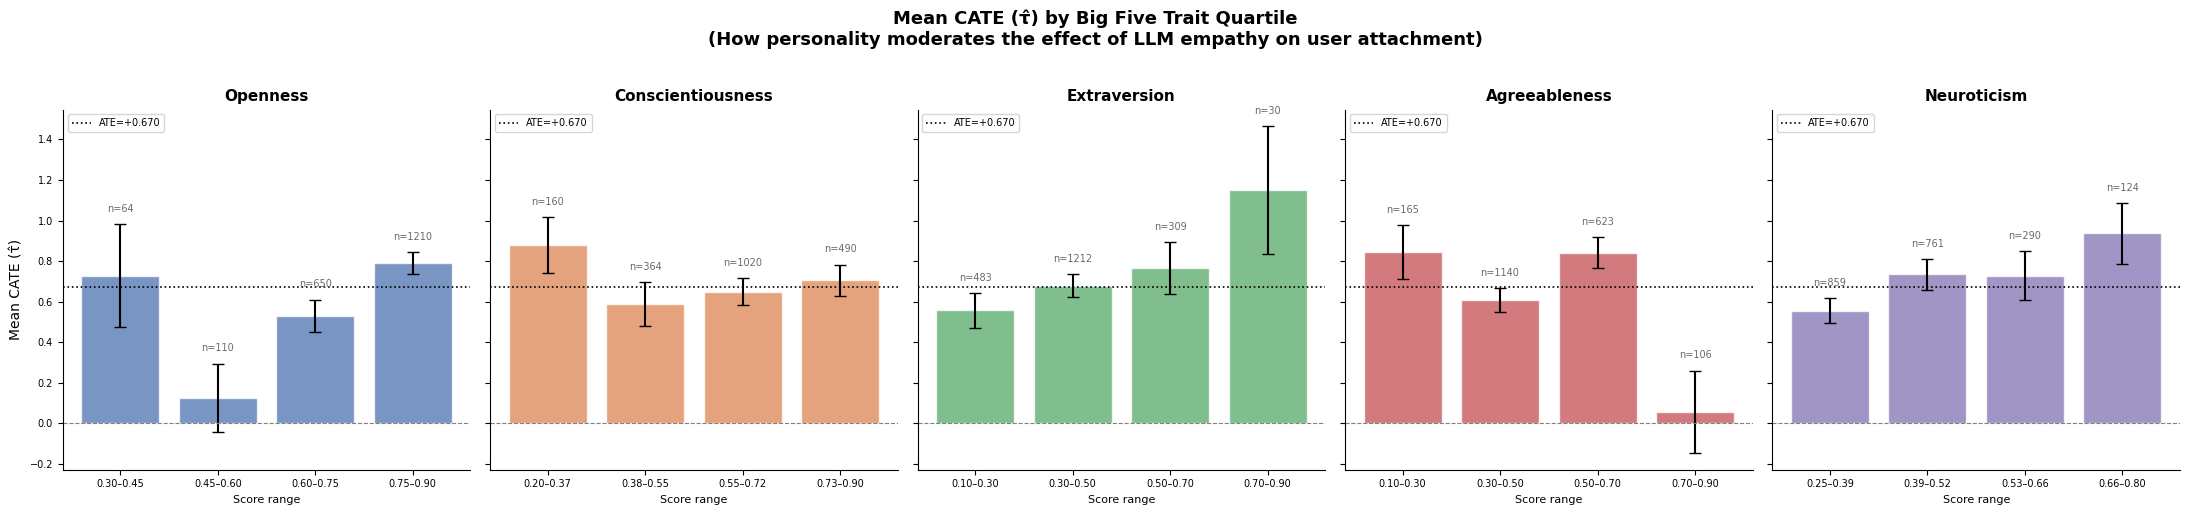

Plot saved → data/cate_by_big_five_quartiles.png


In [ ]:
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
fig.suptitle(
    "Mean CATE (τ̂) by Big Five Trait Quartile\n"
    "(How personality moderates the effect of LLM empathy on user attachment)",
    fontsize=13, fontweight="bold", y=1.02,
)

for ax, trait, color in zip(axes, TRAITS, COLORS):
    t_min, t_max = init_df[trait].min(), init_df[trait].max()
    t_range = t_max - t_min

    bins = [
        t_min - 1e-9,
        t_min + 0.25 * t_range,
        t_min + 0.50 * t_range,
        t_min + 0.75 * t_range,
        t_max + 1e-9,
    ]

    init_df["_q"] = pd.cut(init_df[trait], bins=bins, labels=False)

    grp = init_df.groupby("_q")["tau_hat"]
    means = grp.mean().values
    sems = grp.sem().values
    ci95 = 1.96 * sems
    counts = grp.count().values

    valid_bins = sorted(init_df["_q"].dropna().unique().astype(int))
    range_labels = []
    for b in valid_bins:
        lo = bins[b] + 1e-9  # undo the epsilon so label looks clean
        hi = bins[b + 1] - 1e-9
        range_labels.append(f"{lo:.2f}–{hi:.2f}")

    for i, (mean, count, ci) in enumerate(zip(means, counts, ci95)):
        ax.bar(i, mean, color=color, alpha=0.75, edgecolor="white")
        # n annotation — above bar if positive, below if negative
        y_pos = mean + ci + 0.05 if mean >= 0 else mean - ci - 0.15
        ax.text(i, y_pos, f"n={count}", ha="center", va="bottom", fontsize=7, color="dimgray")

    ax.errorbar(
        range(len(means)),
        means,
        yerr=ci95,
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.5,
    )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axhline(
        np.mean(tau_hat),
        color="black",
        linewidth=1.2,
        linestyle=":",
        label=f"ATE={np.mean(tau_hat):+.3f}",
    )

    ax.set_title(TRAIT_LABELS[trait], fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(range_labels, fontsize=7)
    ax.set_xlabel("Score range", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, loc="upper left")

axes[0].set_ylabel("Mean CATE (τ̂)", fontsize=10)

init_df.drop(columns=["_q"], inplace=True)

plt.tight_layout()
plt.savefig(ROOT / "data" / "cate_by_big_five_quartiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → data/cate_by_big_five_quartiles.png")

## 9. Results Summary

### Why OLS on τ̂?

The DR Learner outputs one estimated treatment effect (τ̂) **per observation** — a high-dimensional, non-linear function of all covariates. To isolate the *marginal* contribution of each Big Five trait to that heterogeneity, we regress τ̂ on the five traits jointly using OLS. This is a standard post-hoc heterogeneity decomposition: the DR Learner is responsible for the causal identification (doubly-robust, cross-fitted), and OLS is simply used as an interpretable lens to ask "holding all other traits fixed, does this one predict who benefits more?". The coefficients are not causal claims about personality — they describe how personality correlates with the treatment effect surface already learned by the DR Learner.

---

### ATE

**ATE = +0.670** — High-empathy LLM responses causally increase user attachment by ~0.67 points on average, after controlling for prompt content, model, and time of day. The wide CATE range confirms strong individual-level heterogeneity: empathy helps most users but the magnitude varies substantially across personalities.

---

### Trait moderators (OLS on τ̂, R² = 0.049)

| Trait | Pearson r | OLS β | Significant? | Interpretation |
|---|---|---|---|---|
| **Openness** | +0.144 | +1.44 | ✅ p < 0.001 | Strongest moderator — open, intellectually curious users are most responsive to empathetic engagement |
| **Neuroticism** | +0.096 | +1.02 | ✅ p < 0.001 | Emotionally sensitive users benefit substantially more from empathetic responses |
| **Extraversion** | +0.078 | +0.77 | ✅ p < 0.001 | Socially oriented users respond more strongly to warm, engaging communication |
| **Agreeableness** | −0.060 | −0.64 | ✅ p < 0.001 | Highly agreeable users benefit less — they engage comfortably regardless of empathy level |
| **Conscientiousness** | −0.012 | +0.18 | ❌ p = 0.26 | No meaningful moderation — organised/disciplined personality does not predict responsiveness to empathy |

The 4.9% of CATE variance explained by personality alone is modest but statistically robust across four of five traits, confirming that Big Five dimensions are genuine moderators of the empathy–attachment causal pathway. The direction of effects aligns with psychological theory: traits associated with emotional depth (Openness, Neuroticism) amplify the treatment effect, while traits associated with social ease (Agreeableness) dampen it.


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Build full moderator matrix: Big Five + model dummies + time dummies
X_ols_full = sm.add_constant(
    np.hstack([
        init_df[TRAITS].values,          # Big Five (5)
        model_dummies.values,            # model one-hot (2)
        time_dummies.values,             # time-of-day one-hot (4)
    ])
)

col_names = (
    ["const"]
    + [TRAIT_LABELS[t] for t in TRAITS]
    + list(model_dummies.columns)
    + list(time_dummies.columns)
)

ols_full = sm.OLS(tau_hat, X_ols_full).fit()

ols_full_summary = pd.DataFrame({
    "Coef":    ols_full.params.round(4),
    "Std Err": ols_full.bse.round(4),
    "t":       ols_full.tvalues.round(3),
    "p-value": ols_full.pvalues.round(4),
}, index=col_names)

print(ols_full_summary.to_string())
print(f"\nR² = {ols_full.rsquared:.4f}  |  Adj. R² = {ols_full.rsquared_adj:.4f}")

                            Coef  Std Err       t  p-value
const                    -0.6840   0.1207  -5.666   0.0000
Openness                  1.2711   0.2058   6.175   0.0000
Conscientiousness         0.1216   0.1559   0.780   0.4354
Extraversion              1.2556   0.1906   6.589   0.0000
Agreeableness            -0.3337   0.1744  -1.914   0.0558
Neuroticism               1.3328   0.1846   7.221   0.0000
model_gpt-3.5-turbo-0301 -0.5517   0.0636  -8.670   0.0000
model_gpt-4-0314         -0.1322   0.0699  -1.891   0.0587
time_afternoon           -0.2907   0.0460  -6.318   0.0000
time_evening              0.1759   0.0432   4.069   0.0000
time_morning             -0.6025   0.0520 -11.598   0.0000
time_night                0.0333   0.0478   0.697   0.4859

R² = 0.1577  |  Adj. R² = 0.1539
